In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import kagglehub
import os

**Dataset from Kaggle**

In [2]:
# Download latest version
path = kagglehub.dataset_download("blurredmachine/are-your-employees-burning-out")
train_csv_path = os.path.join(path, 'train.csv')
test_csv_path = os.path.join(path, 'test.csv')

100%|██████████| 425k/425k [00:00<00:00, 2.59MB/s]

Extracting files...


In [3]:
train = pd.read_csv(train_csv_path)
train = pd.read_csv(train_csv_path)

**Data Overview**

In [ ]:
# Data overview for cleaned dataset
overview_df = train.copy()

print("=== SHAPE ===")
print(overview_df.shape)

print("\n=== COLUMN NAMES ===")
print(overview_df.columns.tolist())

print("\n=== DATA TYPES ===")
print(overview_df.dtypes)

print("\n=== MISSING VALUES ===")
print(overview_df.isnull().sum())

print("\n=== SUMMARY STATISTICS ===")
print(overview_df.describe(include="all").T)

print("\n=== UNIQUE VALUES FOR BINARY / LOW-CARDINALITY COLUMNS ===")
for col in overview_df.columns:
    if overview_df[col].nunique() <= 10:
        print(f"\n{col}:")
        print(overview_df[col].value_counts(dropna=False).sort_index())

=== SHAPE ===
(22750, 9)

=== COLUMN NAMES ===
['Employee ID', 'Date of Joining', 'Gender', 'Company Type', 'WFH Setup Available', 'Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate']

=== DATA TYPES ===
Employee ID              object
Date of Joining          object
Gender                   object
Company Type             object
WFH Setup Available      object
Designation             float64
Resource Allocation     float64
Mental Fatigue Score    float64
Burn Rate               float64
dtype: object

=== MISSING VALUES ===
Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

=== SUMMARY STATISTICS ===
                        count unique                   top   freq      mean  \
Employee ID             22750  22750  fffe3400350031003800      1  

**Data Cleaning**

Drop employee id<br>
Encode Gender, Working From Home, Company Type in training dataset using pandas<br>
Create days since joining and drop date of joining<br>
<br>
days_since_joined was derived from Date of Joining to capture employee tenure in a more usable numeric format. Because all joining dates fall between 2008-01-01 and 2008-12-31, the latest date, 2008-12-31, was used as the reference point. This allows the feature to reflect how long each employee had been with the organization relative to the end of the observed time window.

In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

df_clean = train.copy()

# Drop ID
df_clean = df_clean.drop(columns=["Employee ID"])

# Convert date and create days_since_joined
df_clean["Date of Joining"] = pd.to_datetime(df_clean["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df_clean["days_since_joined"] = (reference_date - df_clean["Date of Joining"]).dt.days
df_clean = df_clean.drop(columns=["Date of Joining"])

# categorical columns will be one hot encoded during modeling process
categorical_columns = [
    "Gender",
    "WFH Setup Available",
    "Company Type"
]

numerical_columns = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined"
]

**Handling missing values & Feature Engineering & scaling**

In [5]:
dfc = df_clean.copy()

missing_count = dfc.isnull().sum()
missing_pct = (dfc.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct
}).sort_values("missing_percent", ascending=False)

print(missing_summary)

                      missing_count  missing_percent
Mental Fatigue Score           2117             9.31
Resource Allocation            1381             6.07
Burn Rate                      1124             4.94
Gender                            0             0.00
Designation                       0             0.00
WFH Setup Available               0             0.00
Company Type                      0             0.00
days_since_joined                 0             0.00


In [6]:
from scipy.stats import ks_2samp

dfc = df_clean.copy()

# Missingness indicators
dfc["mfs_missing"] = dfc["Mental Fatigue Score"].isna().astype(int)
dfc["ra_missing"] = dfc["Resource Allocation"].isna().astype(int)

In [7]:
# functions to run missingness permutation test
def tvd(p, q):
    p, q = p.align(q, fill_value=0)
    return 0.5 * np.abs(p - q).sum()

def categorical_perm_test(df, group_col, cat_col, n_perm=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    observed_tab = pd.crosstab(df[group_col], df[cat_col], normalize='index')
    observed = tvd(observed_tab.loc[0], observed_tab.loc[1])

    stats = []
    for _ in range(n_perm):
        shuffled = df.copy()
        shuffled[cat_col] = rng.permutation(shuffled[cat_col].values)
        tab = pd.crosstab(shuffled[group_col], shuffled[cat_col], normalize='index')
        stat = tvd(tab.loc[0], tab.loc[1])
        stats.append(stat)

    stats = np.array(stats)
    pval = (np.sum(stats >= observed) + 1) / (n_perm + 1)
    return observed, pval

def ks_perm_test(df, group_col, num_col, n_perm=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    temp = df[[group_col, num_col]].dropna().copy()
    g0 = temp.loc[temp[group_col] == 0, num_col]
    g1 = temp.loc[temp[group_col] == 1, num_col]

    observed = ks_2samp(g0, g1).statistic

    stats = []
    for _ in range(n_perm):
        shuffled = temp.copy()
        shuffled[num_col] = rng.permutation(shuffled[num_col].values)
        g0s = shuffled.loc[shuffled[group_col] == 0, num_col]
        g1s = shuffled.loc[shuffled[group_col] == 1, num_col]
        stats.append(ks_2samp(g0s, g1s).statistic)

    stats = np.array(stats)
    pval = (np.sum(stats >= observed) + 1) / (n_perm + 1)
    return observed, pval

Test statistic<br>
categorical: TVD(total variance distance) : distance measure for categorical distribution<br>
numerical: K-S(Kolmogorov-Smirnov statistic) : difference between numerical distribution<br>
<br>
We used TVD for categorical features because it measures differences in category proportions across the missing and non-missing groups, and we used the K-S statistic for numerical features because it compares the full distributions rather than only their means.

In [ ]:
cat_cols = ["gender", "company_type", "is_wfh"]
num_cols = ["Designation", "days_since_joined", "Burn Rate"]

results = []

for target_missing in ["mfs_missing", "ra_missing"]:
    for col in cat_cols:
        stat, pval = categorical_perm_test(dfc[[target_missing, col]].dropna(), target_missing, col)
        results.append([target_missing, col, "categorical_TVD", stat, pval])

    for col in num_cols:
        stat, pval = ks_perm_test(dfc[[target_missing, col]].dropna(), target_missing, col)
        results.append([target_missing, col, "numeric_KS", stat, pval])

results_df = pd.DataFrame(results, columns=["missing_var", "tested_against", "test", "stat", "p_value"])
results_df = results_df.sort_values(["missing_var", "p_value"])
results_df

,missing_var,tested_against,test,stat,p_value
1,mfs_missing,company_type,categorical_TVD,0.011085,0.311344
0,mfs_missing,gender,categorical_TVD,0.010365,0.374313
3,mfs_missing,Designation,numeric_KS,0.013300,0.404298
2,mfs_missing,is_wfh,categorical_TVD,0.007997,0.499250
5,mfs_missing,Burn Rate,numeric_KS,0.016924,0.572714
4,mfs_missing,days_since_joined,numeric_KS,0.013029,0.854573
7,ra_missing,company_type,categorical_TVD,0.021132,0.118941
6,ra_missing,gender,categorical_TVD,0.009139,0.514243
10,ra_missing,days_since_joined,numeric_KS,0.019523,0.657671
11,ra_missing,Burn Rate,numeric_KS,0.018601,0.662669


**Main takeaway from the permutation test**<br>
1. Drop Missing Values for Burn Rate<br>
2. Impute Mental Fatigue Score & Resource Allocation with empirical probabilistic imputation & median as baseline<br>
<br>
Mental Fatigue Score: MCAR-consistent Resource Allocation: MCAR-consistent<br>
<br>
Mental fatigue score & resource allocation is closer to MCAR since none of the p-values were small enough to be significant.<br>
<br>
Although, mental fatigue score could be NMAR since workers with extremely high mental fatigue score would be hesitant to share it, we can not test for this with the data.<br>
<br>
For MCAR, empirical probabilistic imputation is the strongest fit. You fill missing values by randomly sampling from the observed values in that same column. Under MCAR this method gives unbiased estimates of the true mean and variance, unlike single-value imputation.

Removed scaling due to it creating noise for tree based models which made it perform worse

In [38]:
from sklearn.preprocessing import StandardScaler

# Drop rows where Burn Rate is null
df_clean = df_clean.dropna(subset=["Burn Rate"]).copy()

# Columns to impute
cols_to_impute = ["Mental Fatigue Score", "Resource Allocation"]

# -----------------------------
# Median-imputed + engineered
# -----------------------------
df_median = df_clean.copy()

for col in cols_to_impute:
    df_median[col] = df_median[col].fillna(df_median[col].median())

# Feature engineering
df_median["Workload Fatigue Interaction"] = df_median["Resource Allocation"] * df_median["Mental Fatigue Score"]
df_median["Fatigue Ratio"] = df_median["Mental Fatigue Score"] / df_median["Resource Allocation"]
df_median["High Workload"] = np.where(
    df_median["Resource Allocation"] > df_median["Resource Allocation"].median(), 1, 0
)
df_median["High Fatigue"] = np.where(
    df_median["Mental Fatigue Score"] > df_median["Mental Fatigue Score"].median(), 1, 0
)
df_median["Stress Index"] = (
    0.7 * df_median["Mental Fatigue Score"] + 0.3 * df_median["Resource Allocation"]
)


# -----------------------------
# Empirical probabilistic-imputed + engineered
# -----------------------------
df_prob = df_clean.copy()
rng = np.random.default_rng(42)

for col in cols_to_impute:
    missing_mask = df_prob[col].isna()
    observed_values = df_prob.loc[~missing_mask, col].values
    df_prob.loc[missing_mask, col] = rng.choice(
        observed_values,
        size=missing_mask.sum(),
        replace=True
    )

# Feature engineering
df_prob["Workload Fatigue Interaction"] = df_prob["Resource Allocation"] * df_prob["Mental Fatigue Score"]
df_prob["Fatigue Ratio"] = df_prob["Mental Fatigue Score"] / df_prob["Resource Allocation"]
df_prob["High Workload"] = np.where(
    df_prob["Resource Allocation"] > df_prob["Resource Allocation"].median(), 1, 0
)
df_prob["High Fatigue"] = np.where(
    df_prob["Mental Fatigue Score"] > df_prob["Mental Fatigue Score"].median(), 1, 0
)
df_prob["Stress Index"] = (
    0.7 * df_prob["Mental Fatigue Score"] + 0.3 * df_prob["Resource Allocation"]
)

print("Median-imputed + engineered + scaled dataset preview:")
print(df_median.head())

print("\nProbabilistic-imputed + engineered + scaled dataset preview:")
print(df_prob.head())

Median-imputed + engineered + scaled dataset preview:
   Gender Company Type WFH Setup Available  Designation  Resource Allocation  \
0  Female      Service                  No          2.0                  3.0   
1    Male      Service                 Yes          1.0                  2.0   
2  Female      Product                 Yes          2.0                  4.0   
3    Male      Service                 Yes          1.0                  1.0   
4  Female      Service                  No          3.0                  7.0   

   Mental Fatigue Score  Burn Rate  days_since_joined  \
0                   3.8       0.16                 92   
1                   5.0       0.36                 31   
2                   5.8       0.49                296   
3                   2.6       0.20                 58   
4                   6.9       0.52                160   

   Workload Fatigue Interaction  Fatigue Ratio  High Workload  High Fatigue  \
0                          11.4       1.266

**Correlations with Burn Rate**

mental fatigue - burn rate : 0.94<br>
resource allocation - burn rate : 0.86<br>
designation - burn rate : 0.74

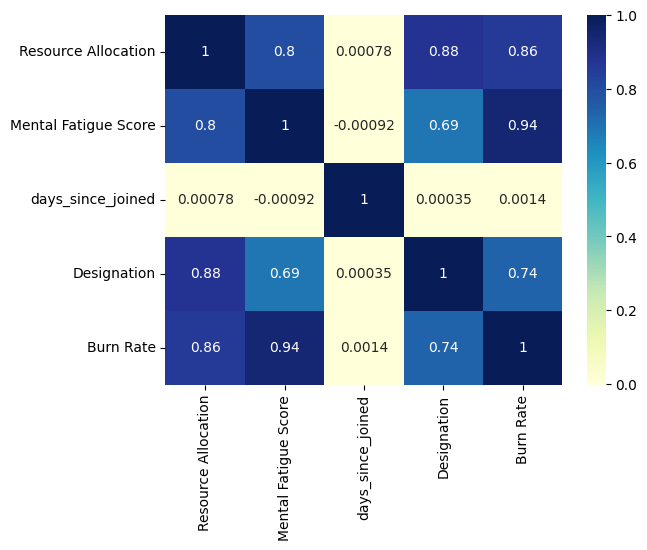

In [ ]:
df_corr = df_clean.copy()
numerics = df_corr[["Resource Allocation", "Mental Fatigue Score", "days_since_joined", "Designation", "Burn Rate"]].corr(numeric_only=True)
sns.heatmap(numerics, cmap="YlGnBu", annot=True)
plt.show()

**WFH hypothesis Test**<br>
Research Question: Is there a difference in employee burn rate by Working From Home Setup?<br>
<br>
Null Hypothesis: There is no statistically significant difference in employee burn rate by Working From Home Setup<br>
<br>
Alternative Hypothesis: There is a statistically significant difference in employee burn rate by Working From Home Setup.<br>
<br>
Conclusion: There is a statistically significant difference in employee burn rate by Working From Home Setup, as the p-value of 0.0000 is below the alpha threshold of 0.05. The effect size (Cohen's d = -0.6638) is small, suggesting the difference, while statistically significant, has limited practical magnitude.<br>

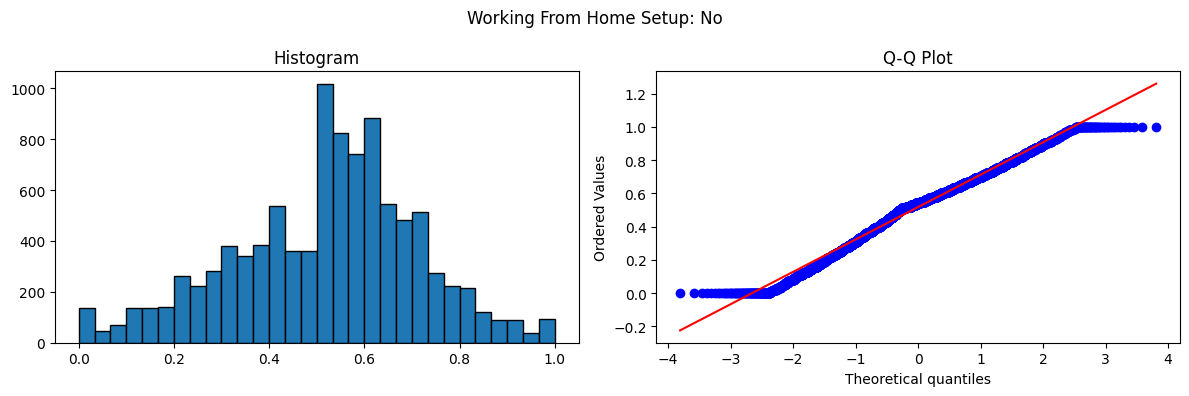

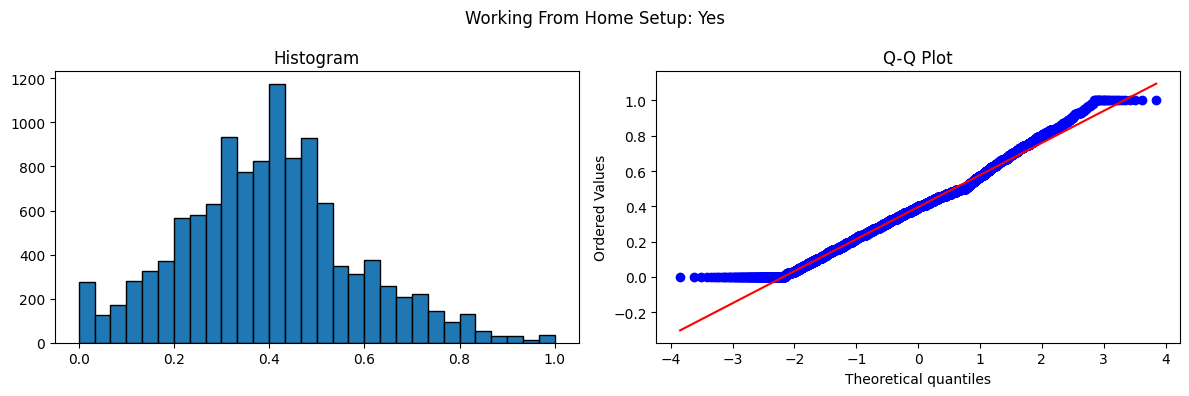

In [ ]:
import scipy.stats as stats

for WFH in train["WFH Setup Available"].unique():
    subset = train[train["WFH Setup Available"] == WFH]["Burn Rate"].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Working From Home Setup: {WFH}")

    axes[0].hist(subset, bins=30, edgecolor="black")
    axes[0].set_title("Histogram")

    stats.probplot(subset, plot=axes[1])
    axes[1].set_title("Q-Q Plot")

    plt.tight_layout()
    plt.show()

In [ ]:
WFH_Yes = train[train["WFH Setup Available"] == "Yes"]["Burn Rate"].dropna()
WFH_No = train[train["WFH Setup Available"] == "No"]["Burn Rate"].dropna()

In [ ]:
from scipy.stats import ttest_ind
stat, p = ttest_ind(WFH_Yes, WFH_No, equal_var=False)
print(f"T-Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

T-Statistic: -47.0352
P-value: 0.0000


In [ ]:
alpha = 0.05
if p < alpha:
    print("Reject H₀ — Burn Rate differs significantly in Burn Rate by WFH Setup Available")
else:
    print("Fail to reject H₀ — No significant difference in Burn Rate by WFH Setup Available")

Reject H₀ — Burn Rate differs significantly in Burn Rate by WFH Setup Available


In [ ]:
cohen_d = (WFH_Yes.mean() - WFH_No.mean()) / np.sqrt((WFH_Yes.std()**2 + WFH_No.std()**2) / 2)
print(f"Effect size (Cohen's d): {cohen_d:.4f}")

Effect size (Cohen's d): -0.6436


**Modeling**

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

**Baseline model**<br>
Linear regression

In [12]:
features = [
    'Gender',
    'Company Type',
    'WFH Setup Available',
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score'
]

categorical_columns = ['Gender', 'Company Type', 'WFH Setup Available']
numerical_columns = ['Designation', 'Resource Allocation', 'Mental Fatigue Score']

def evaluate_linear_regression(df, name):
    X = df[features]
    y = df['Burn Rate']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessed = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first"), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )

    X_train_processed = preprocessed.fit_transform(X_train)
    X_test_processed = preprocessed.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)

    return {
        "dataset": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

results = pd.DataFrame([
    evaluate_linear_regression(df_median, "Median Imputation"),
    evaluate_linear_regression(df_prob, "Probabilistic Imputation")
])

print(results.round(4))

                    dataset    RMSE     MAE      R2
0         Median Imputation  0.0709  0.0535  0.8679
1  Probabilistic Imputation  0.0790  0.0577  0.8361


**Random Forest**

In [13]:
def evaluate_random_forest(df, name):
    X = df[features]
    y = df['Burn Rate']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessed = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first"), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )

    X_train_processed = preprocessed.fit_transform(X_train)
    X_test_processed = preprocessed.transform(X_test)

    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train_processed, y_train)
    y_pred_rf = rf_model.predict(X_test_processed)

    return {
        "dataset": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        "MAE": mean_absolute_error(y_test, y_pred_rf),
        "R2": r2_score(y_test, y_pred_rf)
    }

rf_results = pd.DataFrame([
    evaluate_random_forest(df_median, "Median Imputation"),
    evaluate_random_forest(df_prob, "Probabilistic Imputation")
])

print(rf_results.round(4))

                    dataset    RMSE     MAE      R2
0         Median Imputation  0.0643  0.0496  0.8915
1  Probabilistic Imputation  0.0747  0.0550  0.8534


**Random Forest with feature engineering**

In [17]:
features = [
'Designation',
'Resource Allocation',
'Mental Fatigue Score',
'days_since_joined',
'Gender',
'Company Type',
'WFH Setup Available',
'Workload Fatigue Interaction',
'Fatigue Ratio',
'High Workload',
'High Fatigue',
'Stress Index'
]

categorical_columns = ['Gender', 'Company Type', 'WFH Setup Available']
numerical_columns = ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Workload Fatigue Interaction', 'Fatigue Ratio', 'High Workload', 'High Fatigue', 'Stress Index']

rf_results = pd.DataFrame([
    evaluate_random_forest(df_median, "Median Imputation"),
    evaluate_random_forest(df_prob, "Probabilistic Imputation")
])

print(rf_results.round(4))


                    dataset    RMSE     MAE      R2
0         Median Imputation  0.0643  0.0496  0.8915
1  Probabilistic Imputation  0.0758  0.0552  0.8493


**LightGBM with feature engineering**

In [18]:
def evaluate_lightgbm(df, name):
    X = df[features]
    y = df['Burn Rate']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessed = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first"), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )

    X_train_processed = preprocessed.fit_transform(X_train)
    X_test_processed = preprocessed.transform(X_test)

    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        random_state=42
    )

    lgb_model.fit(X_train_processed, y_train)
    y_pred_lgb = lgb_model.predict(X_test_processed)

    return {
        "dataset": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lgb)),
        "MAE": mean_absolute_error(y_test, y_pred_lgb),
        "R2": r2_score(y_test, y_pred_lgb)
    }

lgb_results = pd.DataFrame([
    evaluate_lightgbm(df_median, "Median Imputation"),
    evaluate_lightgbm(df_prob, "Probabilistic Imputation")
])

print(lgb_results.round(4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 17300, number of used features: 11
[LightGBM] [Info] Start training from score 0.452090


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005715 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 886
[LightGBM] [Info] Number of data points in the train set: 17300, number of used features: 11
[LightGBM] [Info] Start training from score 0.452090


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


                    dataset    RMSE     MAE      R2
0         Median Imputation  0.0599  0.0469  0.9059
1  Probabilistic Imputation  0.0681  0.0505  0.8781


**Gradient Boosting Regressor**

In [20]:
from sklearn import ensemble
from sklearn.ensemble import GradientBoostingRegressor

features = [
    'Gender',
    'Company Type',
    'WFH Setup Available',
    'Designation',
    'Resource Allocation',
    'Mental Fatigue Score',
    'days_since_joined'
]

categorical_columns = ['Gender', 'Company Type', 'WFH Setup Available']
numerical_columns = ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'days_since_joined']

def evaluate_gradient_boosting(df, name):
    X = df[features]
    y = df['Burn Rate']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessed = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first"), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )

    X_train_processed = preprocessed.fit_transform(X_train)
    X_test_processed = preprocessed.transform(X_test)

    params = {
        "n_estimators": 500,
        "max_depth": 4,
        "min_samples_split": 5,
        "learning_rate": 0.01,
        "loss": "squared_error"
    }

    reg = GradientBoostingRegressor(**params)
    reg.fit(X_train_processed, y_train)
    y_pred_gb = reg.predict(X_test_processed)

    return {
        "dataset": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        "MAE": mean_absolute_error(y_test, y_pred_gb),
        "R2": r2_score(y_test, y_pred_gb)
    }

gb_results = pd.DataFrame([
    evaluate_gradient_boosting(df_median, "Median Imputation"),
    evaluate_gradient_boosting(df_prob, "Probabilistic Imputation")
])

print(gb_results.round(4))

                    dataset    RMSE     MAE      R2
0         Median Imputation  0.0612  0.0480  0.9016
1  Probabilistic Imputation  0.0687  0.0517  0.8762


**XgBoost**

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [22]:
!nvidia-smi

Sat May 16 01:41:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
features = [
    'Gender',
    'Company Type',
    'WFH Setup Available',
    'Designation',
    'Resource Allocation',
    'days_since_joined',
    'Mental Fatigue Score'
]

categorical_columns = ['Gender', 'Company Type', 'WFH Setup Available']
numerical_columns = ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'days_since_joined']

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

def evaluate_xgboost_random_search(df, name):
    X = df[features]
    y = df['Burn Rate']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    preprocessed = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(drop="first"), categorical_columns),
            ("num", "passthrough", numerical_columns)
        ]
    )

    X_train_processed = preprocessed.fit_transform(X_train)
    X_test_processed = preprocessed.transform(X_test)

    xgb = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        device="cuda",
        random_state=42
    )

    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=10,
        scoring="neg_root_mean_squared_error",
        cv=3,
        verbose=1,
        random_state=42,
        n_jobs=1
    )

    random_search.fit(X_train_processed, y_train)

    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test_processed)

    return {
        "dataset": name,
        "best_params": random_search.best_params_,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

xgb_median_results = evaluate_xgboost_random_search(df_median, "Median Imputation")
xgb_prob_results = evaluate_xgboost_random_search(df_prob, "Probabilistic Imputation")

xgb_results = pd.DataFrame([
    {
        "dataset": xgb_median_results["dataset"],
        "RMSE": xgb_median_results["RMSE"],
        "MAE": xgb_median_results["MAE"],
        "R2": xgb_median_results["R2"]
    },
    {
        "dataset": xgb_prob_results["dataset"],
        "RMSE": xgb_prob_results["RMSE"],
        "MAE": xgb_prob_results["MAE"],
        "R2": xgb_prob_results["R2"]
    }
])

print(xgb_results.round(4))

print("\nBest params for Median Imputation:")
print(xgb_median_results["best_params"])

print("\nBest params for Probabilistic Imputation:")
print(xgb_prob_results["best_params"])

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [01:45:47] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
                    dataset    RMSE     MAE      R2
0         Median Imputation  0.0602  0.0472  0.9050
1  Probabilistic Imputation  0.0677  0.0506  0.8798

Best params for Median Imputation:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}

Best params for Probabilistic Imputation:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}


**Regression Model comparision**

In [25]:
import pandas as pd

# Add model names
linear_results = results.copy()
linear_results["model"] = "Linear Regression"

rf_results_plot = rf_results.copy()
rf_results_plot["model"] = "Random Forest"

lgb_results_plot = lgb_results.copy()
lgb_results_plot["model"] = "LightGBM"

gb_results_plot = gb_results.copy()
gb_results_plot["model"] = "Gradient Boosting"

xgb_results_plot = xgb_results.copy()
xgb_results_plot["model"] = "XGBoost"

# Combine all results
all_model_results = pd.concat([
    linear_results,
    rf_results_plot,
    lgb_results_plot,
    gb_results_plot,
    xgb_results_plot
], ignore_index=True)

print(all_model_results.round(4))

                    dataset    RMSE     MAE      R2              model
0         Median Imputation  0.0709  0.0535  0.8679  Linear Regression
1  Probabilistic Imputation  0.0790  0.0577  0.8361  Linear Regression
2         Median Imputation  0.0643  0.0496  0.8915      Random Forest
3  Probabilistic Imputation  0.0758  0.0552  0.8493      Random Forest
4         Median Imputation  0.0599  0.0469  0.9059           LightGBM
5  Probabilistic Imputation  0.0681  0.0505  0.8781           LightGBM
6         Median Imputation  0.0612  0.0480  0.9016  Gradient Boosting
7  Probabilistic Imputation  0.0687  0.0517  0.8762  Gradient Boosting
8         Median Imputation  0.0602  0.0472  0.9050            XGBoost
9  Probabilistic Imputation  0.0677  0.0506  0.8798            XGBoost


**Interpretable K means clustering**

In [26]:
# 1. Install Cython if not already present (usually is)
!pip install cython numpy

# 2. Clone the official repository
!git clone https://github.com/navefr/ExKMC.git

# 3. Move into the splitters directory and recompile the .pyx file
%cd ExKMC/ExKMC/splitters/
!cython cut_finder.pyx

# 4. Move back to the root and install
%cd ../..
!python setup.py install

%cd /content

import sys
import os

# This points to where your log said it installed the .egg
sys.path.append('/usr/local/lib/python3.12/dist-packages/ExKMC-0.0.3-py3.12-linux-x86_64.egg')

import graphviz
import re
from IPython.display import SVG, display
from ExKMC.Tree import Tree

Cloning into 'ExKMC'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 127 (delta 57), reused 102 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 1.58 MiB | 23.13 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/ExKMC/ExKMC/splitters
/usr/local/lib/python3.12/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/ExKMC/ExKMC/splitters/cut_finder.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
performance hint: cut_finder.pyx:86:5: Exception check on 'update_col_min_mistakes_cut' will always require the GIL to be acquired.
Possible solutions:
	1. Declare 'update_col_min_mistakes_cut' as 'noexcept' if you control the definition and you're sure you don't want the function to raise exceptions.
	2. Use an 'int' return typ

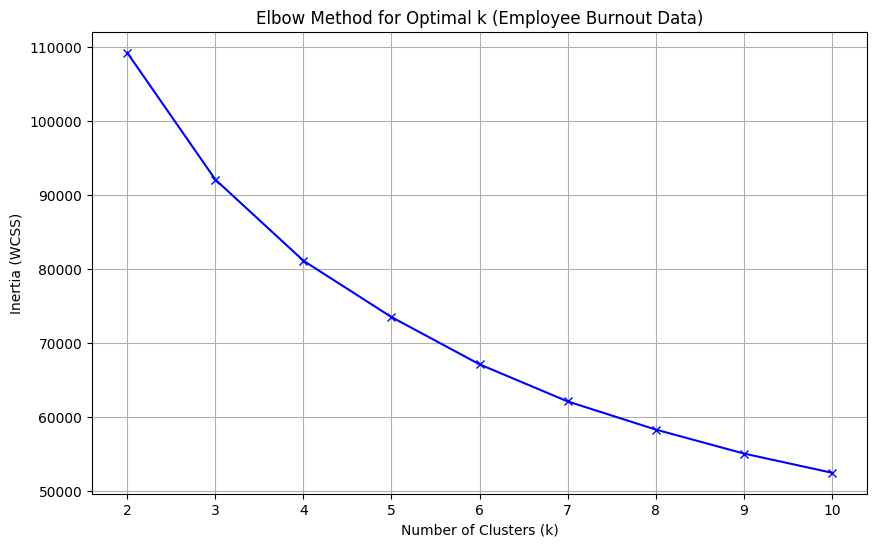

In [43]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df_k = df_prob.copy()
# 1. Prepare features for clustering
# We exclude 'Burn Rate' from the clustering itself so we can use it to validate the clusters later
df_k["gender"] = df_prob["Gender"].map({"Male": 1, "Female": 0})
df_k["company_type"] = df_prob["Company Type"].map({"Service": 1, "Product": 0})
df_k["is_wfh"] = df_prob["WFH Setup Available"].map({"Yes": 1, "No": 0})
df_k = df_k.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

cluster_features = [col for col in df_k.columns if col not in ['Burn Rate']]

# Continuous columns to scale
scale_cols = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined",
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "Stress Index"
]

scaler_prob = StandardScaler()
df_k[scale_cols] = scaler_prob.fit_transform(df_k[scale_cols])

X_elbow = df_k[cluster_features]

# 2. Run Elbow Test
wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_elbow)
    wcss.append(kmeans.inertia_)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k (Employee Burnout Data)')
plt.grid(True)
plt.show()


Visualizing Employee Burnout Personas (k=4, max_leaves=8):


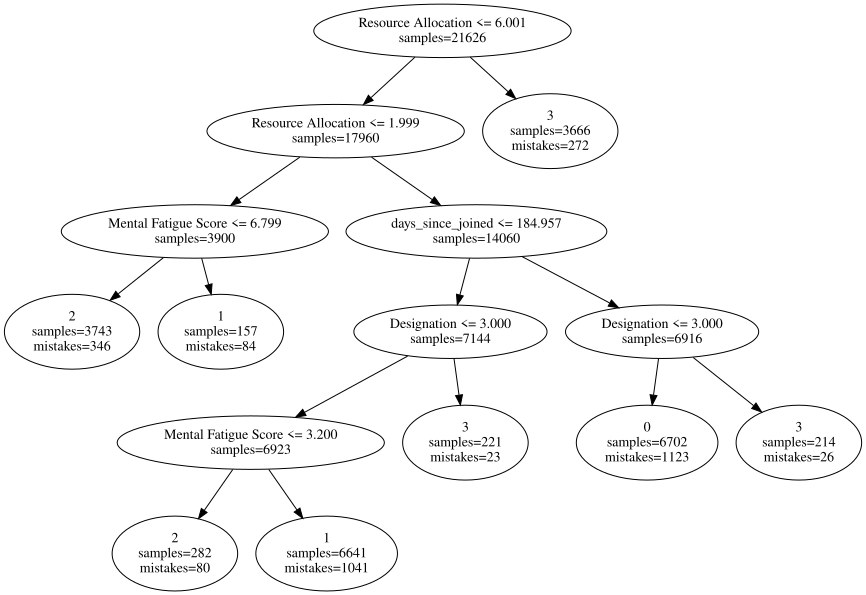


--- Employee Burnout Persona Report ---


,Avg_Burn_Rate,Avg_Fatigue_Score,Avg_Resources,Avg_Designation,Avg_Days_Joined,WFH_Percent,Percent_Male,Employee_Count
burnout_cluster,,,,,,,,
3.0,0.689734,7.550378,7.447940,3.675689,181.537430,32.7%,58.2%,4101
1.0,0.456362,5.976625,4.412768,2.135040,96.222860,55.6%,47.1%,6798
0.0,0.449430,5.802059,4.433602,2.121009,275.883169,55.9%,46.2%,6702
2.0,0.206718,3.350634,1.684224,0.823602,174.450186,69.9%,39.5%,4025


In [44]:
# 1. Configuration
k_optimal = 4

# Add the engineered interaction terms to the forbidden list
engineered_cols = [
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "High Workload",
    "High Fatigue",
    "Stress Index"
]
forbidden_cols = ['Burn Rate', 'burnout_cluster', 'Employee ID'] + engineered_cols

all_features = [col for col in df_k.columns if col not in forbidden_cols]

X_final = df_k[all_features].values

# 2. Fit ExKMC
model_tree = Tree(k=k_optimal, max_leaves=8, random_state=42)
model_tree.fit(X_final)

# 3. Generate Labels
df_k['burnout_cluster'] = model_tree.predict(X_final)

# 4. Explainable Plotting with Inverse Scaling
gv_file = 'burnout_tree.gv'
try:
    model_tree.plot('burnout_tree', feature_names=all_features, view=False)

    with open(gv_file, 'r') as f:
        dot_data = f.read()

    def inverse_transform_burnout(match):
        feature, threshold = match.group(1).strip(), float(match.group(2))
        # Ensure we only try to scale columns that were originally part of scale_cols
        if feature in scale_cols:
            idx = scale_cols.index(feature)
            original_val = (threshold * np.sqrt(scaler_prob.var_[idx])) + scaler_prob.mean_[idx]
            return f'{feature} <= {original_val:.3f}'
        return match.group(0)

    readable_dot_data = re.sub(r'([\w_ ]+) <= ([-+]?\d*\.\d+|\d+)', inverse_transform_burnout, dot_data)

    print(f"\nVisualizing Employee Burnout Personas (k={k_optimal}, max_leaves=8):")
    s = graphviz.Source(readable_dot_data, filename="burnout_tree_final", format="svg")
    display(SVG(s.render(cleanup=True)))

except Exception as e:
    print(f"Visualization failed: {e}")

# 5. Burnout Persona Summary
print("\n--- Employee Burnout Persona Report ---")

df_report = df_k.copy()
# Only unscale columns that are still in our reporting set
for col in [c for c in scale_cols if c in df_report.columns]:
    idx = scale_cols.index(col)
    df_report[col] = (df_k[col] * np.sqrt(scaler_prob.var_[idx])) + scaler_prob.mean_[idx]

summary = df_report.groupby('burnout_cluster').agg({
    'Burn Rate': 'mean',
    'Mental Fatigue Score': 'mean',
    'Resource Allocation': 'mean',
    'Designation': 'mean',
    'days_since_joined': 'mean',
    'is_wfh': 'mean',
    'gender': ['mean', 'count']
})

# 6. Clean up Column Names
summary.columns = [
    'Avg_Burn_Rate',
    'Avg_Fatigue_Score',
    'Avg_Resources',
    'Avg_Designation',
    'Avg_Days_Joined',
    'WFH_Percent',
    'Percent_Male',
    'Employee_Count'
]

# 7. Format for readability
summary['WFH_Percent'] = (summary['WFH_Percent'] * 100).round(1).astype(str) + '%'
summary['Percent_Male'] = (summary['Percent_Male'] * 100).round(1).astype(str) + '%'

display(summary.sort_values(by='Avg_Burn_Rate', ascending=False))

Cluster 3: The High-Load "At-Risk" Segment<br>
This cluster is found via three different paths, but they all share a common theme of high pressure.The Primary Group: Employees with Resource Allocation > 6.0. This is the tree's very first split, indicating that extreme workload is the #1 identifier for this persona.The "Tenured Under-Performer": Employees with moderate resources (between 2 and 6) but who have been with the company a long time (> 185 days) and have a high designation (> 3.0).Persona: These are your "Workhorses." They are likely the most senior people carrying the heaviest project loads.<br>
Cluster 2:  The Low-Resource "Quiet" Group<br>
The Path: Low Resource Allocation ($\le$ 1.9) AND Low Fatigue ($\le$ 6.8).Persona: These employees have manageable workloads and healthy mental fatigue scores. They represent the "Safe Zone" of your organization where burn rate is likely at its lowest.<br>
Cluster 1:The "Fatigued Newbies"<br>
The Path: Moderate resources (2 to 6) but very high Mental Fatigue (> 6.8). Another significant group shows up for those with low tenure ($\le$ 185 days) who have moderate fatigue (> 3.2).Persona: This is a "Warning" segment. Even if their actual resource count isn't the highest, their subjective fatigue is high. The tenure split suggests that newer employees might be struggling with the learning curve or lack of support, leading to fatigue even without "extreme" workloads.<br>
Cluster 0: The "Mid-Tier Managers"<br>
The Path: Moderate resources (2 to 6), long tenure (> 185 days), but a lower designation ($\le$ 3.0).Persona: These are your established, mid-level staff. They have survived the initial "newbie" phase and haven't yet been promoted into the high-stress, high-resource "Cluster 3" roles. They are the stable core of the workforce.

Key Takeaways from the 8-Leaf Expansion<br>
1. Resource Allocation is the King Split: The model immediately separates the "Extreme Workload" (Cluster 3) from everyone else.<br>

2. The "185-Day" Milestone: The tree reveals that tenure significantly changes how employees experience their workload. Employees who have been around for more than 6 months are processed through a different logic (Designation) than those who are newer.<br>

3. Redundancy for Accuracy: Notice how Cluster 1 and Cluster 3 appear in multiple leaves. This is ExKMC doing its job—it's using multiple "rectangles" to more accurately capture the shape of those burnout personas than a simple 4-leaf tree ever could.<br>